api get data

In [1]:
import pandas as pd
import yfinance as yf
from datetime import datetime
import math
import time

df = pd.read_csv("primary_ticker_only.csv")

df_clean = df.rename(columns={
    "ticker": "ticker",
    "title": "company_name",
    "CIK": "cik",
    "SIC": "sic",
    "SIC_description": "sic_description"
})

df_clean["cik"] = df_clean["cik"].astype(str).str.zfill(10)
df_clean = df_clean.reset_index(drop=True).copy()
df_clean.insert(0, "company_id", df_clean.index + 1)

company_out = df_clean[["company_id", "cik", "ticker", "company_name", "sic", "sic_description"]].copy()
company_out.to_csv("company.csv", header=False, index=False)

FIXED_START = "2015-11-28"
TODAY = "2025-11-27"

def fetch_price_fixed_window(ticker: str):
    try:
        dfp = yf.download(
            ticker,
            start=FIXED_START,
            end=TODAY,
            auto_adjust=False,
            progress=False
        )
        if dfp is None or dfp.empty:
            return None
        if isinstance(dfp.columns, pd.MultiIndex):
            try:
                dfp = dfp.xs(ticker, axis=1, level=-1)
            except Exception:
                dfp.columns = [c[0] for c in dfp.columns]
        dfp = dfp.reset_index()
        dfp = dfp.rename(columns={
            "Date": "trade_date",
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })
        dfp = dfp[["trade_date", "open", "high", "low", "close", "adj_close", "volume"]]
        return dfp
    except Exception:
        return None

df_comp = company_out[["company_id", "ticker"]].drop_duplicates()

daily_rows = []

for _, row in df_comp.iterrows():
    cid = int(row["company_id"])
    ticker = str(row["ticker"]).strip().upper()
    dfp = fetch_price_fixed_window(ticker)
    if dfp is None:
        continue

    for rec in dfp.itertuples(index=False, name=None):
        trade_date_raw, open_raw, high_raw, low_raw, close_raw, adj_close_raw, vol_raw = rec

        if isinstance(trade_date_raw, pd.Timestamp):
            trade_date = trade_date_raw.strftime("%Y-%m-%d")
        else:
            trade_date = pd.to_datetime(trade_date_raw).strftime("%Y-%m-%d")

        def to_num(x):
            if x is None:
                return None
            if isinstance(x, float) and math.isnan(x):
                return None
            return float(x)

        open_ = to_num(open_raw)
        high_ = to_num(high_raw)
        low_ = to_num(low_raw)
        close_ = to_num(close_raw)
        adj_close_ = to_num(adj_close_raw)

        if vol_raw is None or (isinstance(vol_raw, float) and math.isnan(vol_raw)):
            vol = None
        else:
            vol = int(vol_raw)

        daily_rows.append([cid, trade_date, open_, high_, low_, close_, adj_close_, vol])

    time.sleep(0.10)

daily_price_out = pd.DataFrame(
    daily_rows,
    columns=["company_id", "date", "open", "high", "low", "close", "adj_close", "volume"]
)

for col in ["open", "high", "low", "close", "adj_close"]:
    daily_price_out[col] = pd.to_numeric(daily_price_out[col], errors="coerce").round(4)

daily_price_out["volume"] = pd.to_numeric(daily_price_out["volume"], errors="coerce").fillna(0).astype("int64")
daily_price_out = daily_price_out.sort_values(["company_id", "date"])
daily_price_out = daily_price_out.drop_duplicates(subset=["company_id", "date"], keep="last")

daily_price_out.to_csv("daily_price.csv", header=False, index=False, float_format="%.4f")


1 Failed download:
['OBLG']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27) (Yahoo error = "No data found, symbol may be delisted")')

1 Failed download:
['LNW']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27) (Yahoo error = "Data doesn\'t exist for startDate = 1448686800, endDate = 1764219600")')

1 Failed download:
['SPNS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27) (Yahoo error = "No data found, symbol may be delisted")')

1 Failed download:
['UMEWF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27) (Yahoo error = "No data found, symbol may be delisted")')

1 Failed download:
['VRNT']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27)')

1 Failed download:
['TRUE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-11-28 -> 2025-11-27) (Ya

Three-week repricing clustering（1/27–2/10)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import yfinance as yf


company = pd.read_csv(
    "company.csv",
    header=None,
    names=["company_id", "cik", "ticker", "company_name", "sic", "sic_description"]
)

price = pd.read_csv(
    "daily_price.csv",
    header=None,
    names=["company_id", "date", "open", "high", "low", "close", "adj_close", "volume"]
)

# Clean types
company["ticker"] = company["ticker"].astype(str).str.upper().str.strip()
price["date"] = pd.to_datetime(price["date"], errors="coerce")

company = company.dropna(subset=["company_id", "ticker"]).drop_duplicates(subset=["company_id"])
price = price.dropna(subset=["company_id", "date"]).copy()

print("company shape:", company.shape)
print("price shape:", price.shape)

company shape: (927, 6)
price shape: (1560981, 8)


Merge company info into daily prices
Add coverage filter (>=252 trading days)
Add liquidity filter (avg dollar volume). set LIQ_THRESHOLD = 2_000_000

In [4]:
merged = price.merge(company, on="company_id", how="inner")
merged = merged.dropna(subset=["ticker", "adj_close"]).copy()
print("merged rows:", len(merged))
print("unique tickers:", merged["ticker"].nunique())

coverage = merged.groupby("ticker")["date"].nunique()
valid_tickers_cov = coverage[coverage >= 252].index
merged_cov = merged[merged["ticker"].isin(valid_tickers_cov)].copy()
print("after coverage filter tickers:", merged_cov["ticker"].nunique())

merged_cov["dollar_volume"] = merged_cov["close"] * merged_cov["volume"]
liq = merged_cov.groupby("ticker")["dollar_volume"].mean()
LIQ_THRESHOLD = 2_000_000
valid_tickers_liq = liq[liq >= LIQ_THRESHOLD].index
merged_filt = merged_cov[merged_cov["ticker"].isin(valid_tickers_liq)].copy()
print("after liquidity filter tickers:", merged_filt["ticker"].nunique())

merged rows: 1560981
unique tickers: 882
after coverage filter tickers: 824
after liquidity filter tickers: 518


Download SPY (MultiIndex safe) + compute spy returns

In [5]:
spy_df = yf.download(
    "SPY",
    start="2024-12-01",
    end="2025-03-01",
    progress=False,
    auto_adjust=False
)

# In your environment, columns are MultiIndex: ("Close","SPY") exists
spy = spy_df[("Close", "SPY")].pct_change().to_frame("spy_ret").reset_index()
spy.columns = ["date", "spy_ret"]
spy["date"] = pd.to_datetime(spy["date"])

# Merge SPY returns
merged_filt["date"] = pd.to_datetime(merged_filt["date"])
merged_filt = merged_filt.merge(spy, on="date", how="left")
print("missing spy_ret rate:", merged_filt["spy_ret"].isna().mean())

missing spy_ret rate: 0.9693309650680876


Compute daily stock returns + abnormal returns

In [6]:
merged_filt = merged_filt.sort_values(["ticker", "date"])
merged_filt["ret"] = merged_filt.groupby("ticker")["adj_close"].pct_change()
merged_filt["abret"] = merged_filt["ret"] - merged_filt["spy_ret"]

print("missing ret rate:", merged_filt["ret"].isna().mean())
print("missing abret rate:", merged_filt["abret"].isna().mean())

missing ret rate: 0.0005198141513883453
missing abret rate: 0.9693309650680876


Repricing window (3 weeks): 2025-01-27 to 2025-02-10

In [7]:
start_date = pd.to_datetime("2025-01-27")
end_date   = pd.to_datetime("2025-02-10")

window = merged_filt[
    (merged_filt["date"] >= start_date) &
    (merged_filt["date"] <= end_date)
].copy()

print("repricing window rows:", len(window))
print("tickers in window:", window["ticker"].nunique())

repricing window rows: 5698
tickers in window: 518


Build repricing features per ticker
- CAR: cumulative abnormal return (sum of daily abnormal returns)
- MaxDrawdown: worst drawdown over the window
- Volatility: std of daily returns
- MeanReturn: mean of daily returns

In [8]:
car = window.groupby("ticker")["abret"].sum()

def max_drawdown(ret_series: pd.Series) -> float:
    r = ret_series.dropna()
    if len(r) == 0:
        return np.nan
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()

# Keep drawdown/volatility on raw returns to reflect realized downside risk
mdd = window.groupby("ticker")["ret"].apply(max_drawdown)
vol = window.groupby("ticker")["ret"].std()

features = pd.concat([car, mdd, vol], axis=1)
features.columns = ["CAR", "MaxDrawdown", "Volatility"]
features = features.dropna()

print("features shape:", features.shape)
display(features.head())
print(features.corr())

features shape: (518, 3)


,CAR,MaxDrawdown,Volatility
ticker,,,
AAOI,0.036358,-0.079800,0.082699
AAPL,0.029878,-0.049005,0.021413
ACIW,0.020732,-0.035382,0.014444
ADBE,0.041523,-0.028991,0.015295
ADI,-0.053130,-0.049021,0.015042


                  CAR  MaxDrawdown  Volatility
CAR          1.000000     0.293607    0.454394
MaxDrawdown  0.293607     1.000000   -0.592510
Volatility   0.454394    -0.592510    1.000000


Quick check: distribution of CAR

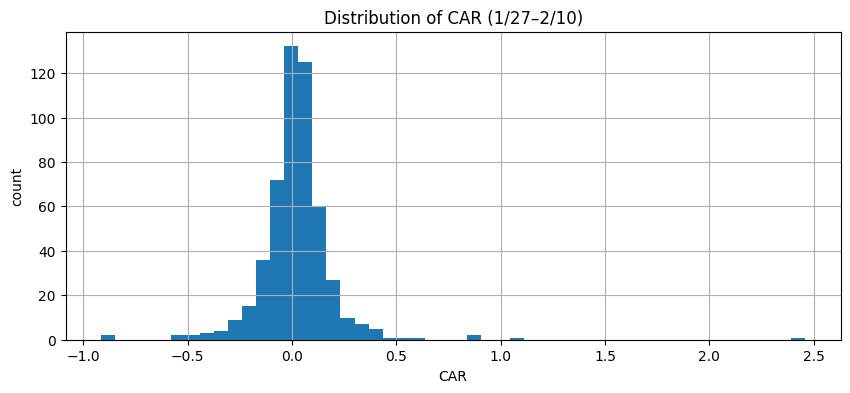

In [9]:
plt.figure(figsize=(10,4))
features["CAR"].hist(bins=50)
plt.title("Distribution of CAR (1/27–2/10)")
plt.xlabel("CAR")
plt.ylabel("count")
plt.show()

Standardize features
Choose K: Elbow + Silhouette

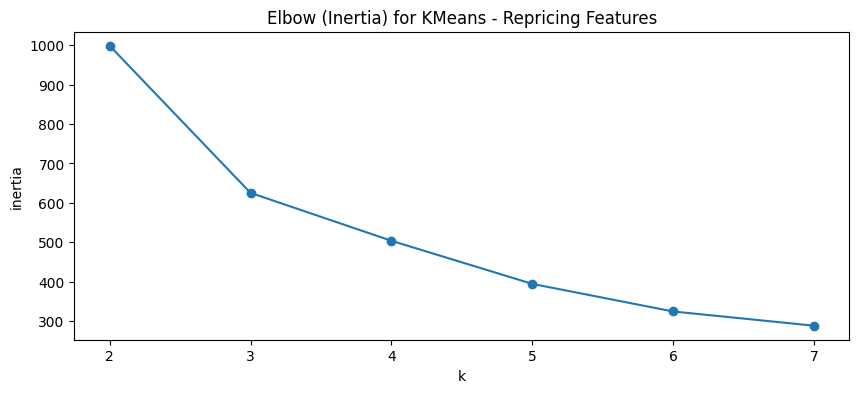

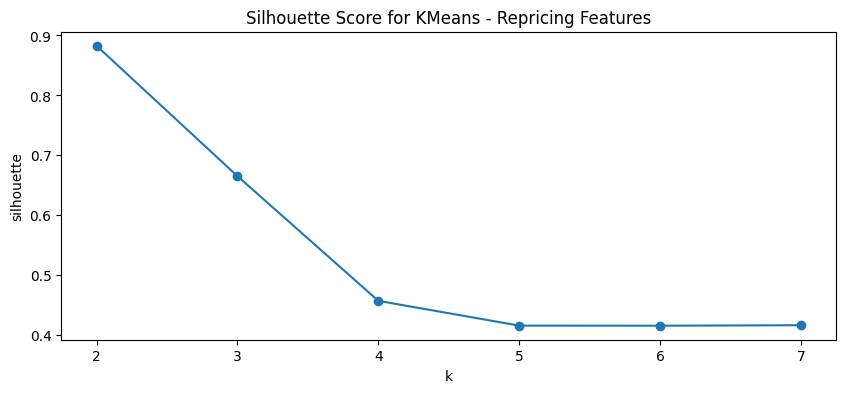

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features.values)

inertia = []
sil = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_k = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels_k))

plt.figure(figsize=(10,4))
plt.plot(list(k_range), inertia, marker="o")
plt.title("Elbow (Inertia) for KMeans - Repricing Features")
plt.xlabel("k")
plt.ylabel("inertia")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(k_range), sil, marker="o")
plt.title("Silhouette Score for KMeans - Repricing Features")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.show()

Fit KMeans with chosen K

In [20]:
K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

features_clustered = features.copy()
features_clustered["cluster"] = labels

print("\nCluster sizes:")
print(features_clustered["cluster"].value_counts())

print("\nCluster means (interpretation table):")
display(features_clustered.groupby("cluster").mean())


Cluster sizes:
cluster
1    514
0      4
Name: count, dtype: int64

Cluster means (interpretation table):


,CAR,MaxDrawdown,Volatility
cluster,,,
0,1.215376,-0.449838,0.515719
1,0.014003,-0.078784,0.039700


PCA visualization

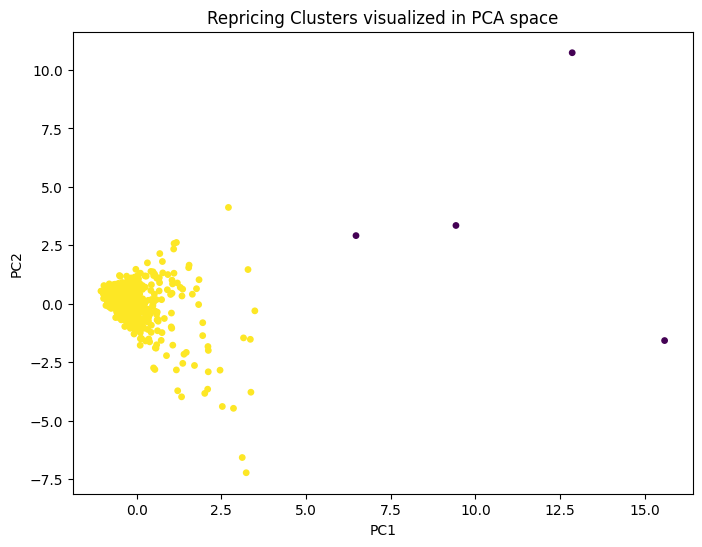

Explained variance ratio: [0.54173214 0.42650374]


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=15)
plt.title("Repricing Clusters visualized in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Attach cluster labels back to company info (for story)

In [13]:
cluster_map = features_clustered["cluster"].reset_index()  # columns: ticker, cluster
company_clustered = company.merge(cluster_map, on="ticker", how="inner")

print("\nTop SIC descriptions by cluster:")
display(company_clustered.groupby("cluster")["sic_description"].value_counts().head(30))

print("\nExample rows:")
display(company_clustered.head())


Top SIC descriptions by cluster:


cluster  sic_description                                            
0        Services-Prepackaged Software                                    2
         Services-Computer Processing & Data Preparation                  1
         Services-Computer Programming Services                           1
1        Services-Prepackaged Software                                  162
         Semiconductors & Related Devices                                79
         Services-Computer Programming, Data Processing, Etc.            53
         Services-Computer Processing & Data Preparation                 49
         Services-Computer Integrated Systems Design                     26
         Retail-Catalog & Mail-Order Houses                              22
         Radio & Tv Broadcasting & Communications Equipment              17
         Services-Computer Programming Services                          17
         Communications Equipment, NEC                                    9
         Computer P


Example rows:


,company_id,cik,ticker,company_name,sic,sic_description,cluster
0,2,2488,AMD,ADVANCED MICRO DEVICES INC,3674,Semiconductors & Related Devices,1
1,3,4127,SWKS,"SKYWORKS SOLUTIONS, INC.",3674,Semiconductors & Related Devices,1
2,4,6281,ADI,ANALOG DEVICES INC,3674,Semiconductors & Related Devices,1
3,5,6951,AMAT,APPLIED MATERIALS INC /DE,3674,Semiconductors & Related Devices,1
4,7,8670,ADP,AUTOMATIC DATA PROCESSING INC,7374,Services-Computer Processing & Data Preparation,1


In [14]:
counts = features_clustered["cluster"].value_counts()
print("Cluster counts:\n", counts)

single_clusters = counts[counts == 1].index.tolist()
print("Single-member clusters:", single_clusters)

if len(single_clusters) > 0:
    outlier_tickers = features_clustered.loc[
        features_clustered["cluster"].isin(single_clusters)
    ].index.tolist()
    print("Outlier tickers:", outlier_tickers)
    features_clean = features_clustered.drop(index=outlier_tickers).copy()
else:
    print("No single-member clusters found.")
    features_clean = features_clustered.copy()

print("After removal:", features_clean["cluster"].value_counts())

Cluster counts:
 cluster
1    514
0      4
Name: count, dtype: int64
Single-member clusters: []
No single-member clusters found.
After removal: cluster
1    514
0      4
Name: count, dtype: int64


In [15]:
start_date = pd.to_datetime("2025-01-27")
end_date   = pd.to_datetime("2025-02-10")
tickers_keep = features_clean.index.tolist()

w = merged_filt[
    (merged_filt["ticker"].isin(tickers_keep)) &
    (merged_filt["date"] >= start_date) &
    (merged_filt["date"] <= end_date)
].sort_values(["ticker","date"]).copy()

start_px = w.groupby("ticker").first().reset_index()[["ticker","date","adj_close"]]
start_px = start_px.rename(columns={"date":"start_date_actual","adj_close":"start_price"})

end_px = w.groupby("ticker").last().reset_index()[["ticker","date","adj_close"]]
end_px = end_px.rename(columns={"date":"end_date_actual","adj_close":"end_price"})

y_df = start_px.merge(end_px, on="ticker", how="inner")
y_df["raw_return"] = y_df["end_price"] / y_df["start_price"] - 1

spy_price = spy_df[("Close","SPY")].copy()
spy_price.index = pd.to_datetime(spy_price.index)

spy_start = spy_price.loc[spy_price.index >= start_date].iloc[0]
spy_end   = spy_price.loc[spy_price.index <= end_date].iloc[-1]
spy_window_ret = spy_end / spy_start - 1

y_df["normal_return_spy"] = float(spy_window_ret)
y_df["excess_return"] = y_df["raw_return"] - y_df["normal_return_spy"]

y_df = y_df.merge(
    features_clean.reset_index()[["ticker","cluster","CAR","MaxDrawdown","Volatility"]],
    on="ticker",
    how="left"
)

cluster_car = features_clean.groupby("cluster")["CAR"].mean().sort_values()
vul_cluster = cluster_car.index[0]
y_df["label"] = np.where(y_df["cluster"] == vul_cluster, "Vulnerable", "Resilient")

print("SPY window return:", y_df["normal_return_spy"].iloc[0])
print(y_df["label"].value_counts())

y_df.to_csv("deepseek_Y_table_0127_0210_car.csv", index=False)
print("saved deepseek_Y_table_0127_0210_car.csv rows:", len(y_df))

SPY window return: 0.009142900901601747
label
Vulnerable    514
Resilient       4
Name: count, dtype: int64
saved deepseek_Y_table_0127_0210_car.csv rows: 518


In [16]:
final_tickers = features_clean.index.unique().tolist()
pd.Series(final_tickers, name="ticker").to_csv("deepseek_final_ticker_list_car.csv", index=False)
print("Exported tickers:", len(final_tickers))

Exported tickers: 518


In [17]:
features_clean.reset_index()[["ticker", "cluster"]].to_csv(
    "deepseek_ticker_with_cluster_car.csv",
    index=False
)

In [18]:
company_export = company.merge(
    features_clean.reset_index()[["ticker","cluster"]],
    on="ticker",
    how="inner"
)

company_export[["ticker", "company_name", "sic", "sic_description", "cluster"]].to_csv(
    "deepseek_company_info_with_cluster_car.csv",
    index=False
)

print("Exported company info rows:", len(company_export))

Exported company info rows: 518
